# Notebook 3 — Creación del Dataset de Clasificación Binaria

## Objetivo
Transformar el dataset crudo de vulnerabilidades (`vulnerability_fix_dataset.csv`) en un dataset binario listo para entrenar el clasificador XGBoost.

### Lógica de etiquetado
| Columna origen | Etiqueta | Significado |
|---|---|---|
| `vulnerable_code` | **1 (VULNERABLE)** | Código con vulnerabilidad conocida |
| `fixed_code` | **0 (SEGURO)** | Código corregido / seguro |

### Dataset de salida
- Archivo: `data/processed/security_dataset.csv`
- Columnas: `code`, `label`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print('Bibliotecas cargadas correctamente')

Bibliotecas cargadas correctamente


## 1. Cargar dataset crudo

In [2]:
RAW_PATH = Path('../data/raw/vulnerability_fix_dataset.csv')
OUT_PATH = Path('../data/processed/security_dataset.csv')

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH, encoding='utf-8', on_bad_lines='skip')

print(f'Registros cargados : {len(df):,}')
print(f'Columnas           : {list(df.columns)}')
df.head(3)

Registros cargados : 35,000
Columnas           : ['vulnerability_type', 'vulnerable_code', 'fixed_code']


,vulnerability_type,vulnerable_code,fixed_code
0,SQL Injection,import java.sql.*;\n\npublic class SQLInjectio...,import java.sql.*;\n\npublic class SQLInjectio...
1,SQL Injection,import java.sql.*;\n\npublic class VulnerableS...,import java.sql.*;\n\npublic class SecureSQLIn...
2,SQL Injection,import java.sql.*;\n\npublic class SQLInjectio...,To prevent SQL Injection attacks in the provid...


## 2. Limpieza

### 2.1 Eliminar duplicados

In [3]:
antes = len(df)
df = df.drop_duplicates()
despues = len(df)
print(f'Duplicados eliminados : {antes - despues:,}')
print(f'Registros restantes   : {despues:,}')

Duplicados eliminados : 2,517
Registros restantes   : 32,483


### 2.2 Eliminar registros donde `fixed_code` es texto explicativo en inglés

Algunos registros del dataset contienen explicaciones en lenguaje natural en lugar de código Java corregido. Estos no son útiles para entrenar el clasificador.

In [4]:
PATRONES_TEXTO = [
    'To fix', 'Here\'s', 'Here is',
    'You should', 'One way', 'To prevent'
]

mask_texto = df['fixed_code'].astype(str).str.startswith(tuple(PATRONES_TEXTO))
print(f'Registros con texto explicativo en fixed_code: {mask_texto.sum():,}')

df = df[~mask_texto]
print(f'Registros tras filtrado: {len(df):,}')

Registros con texto explicativo en fixed_code: 11,395
Registros tras filtrado: 21,088


## 3. Construir dataset binario

Cada fila del dataset crudo genera **dos** muestras:
- `vulnerable_code` → label **1** (VULNERABLE)
- `fixed_code` → label **0** (SEGURO)

In [5]:
vulnerables = pd.DataFrame({
    'code' : df['vulnerable_code'],
    'label': 1
})

seguros = pd.DataFrame({
    'code' : df['fixed_code'],
    'label': 0
})

security_dataset = pd.concat([vulnerables, seguros], ignore_index=True)

# Eliminar filas con código nulo o vacío
security_dataset = security_dataset.dropna(subset=['code'])
security_dataset = security_dataset[security_dataset['code'].str.strip().str.len() > 0]

print(f'Total de muestras antes de mezclar: {len(security_dataset):,}')
print()
print('Distribución de clases:')
print(security_dataset['label'].value_counts())

Total de muestras antes de mezclar: 42,176

Distribución de clases:
label
1    21088
0    21088
Name: count, dtype: int64


## 4. Mezcla aleatoria (shuffle)

Para evitar que el modelo vea primero todos los vulnerables y luego todos los seguros.

In [6]:
security_dataset = security_dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(f'Shape final: {security_dataset.shape}')
security_dataset.head()

Shape final: (42176, 2)


,code,label
0,import java.sql.*;\n\npublic class SecureCode ...,0
1,import java.sql.*;\n\npublic class SecureApp {...,0
2,import java.io.BufferedReader;\nimport java.io...,1
3,import java.sql.Connection;\nimport java.sql.D...,1
4,import java.sql.Connection;\nimport java.sql.D...,0


## 5. Verificación del balance

=== BALANCE DEL DATASET FINAL ===
  SEGURO      : 21,088 (50.00%)
  VULNERABLE  : 21,088 (50.00%)

  Ratio desbalance : 1.000:1
  Estado           : ✓ BALANCEADO


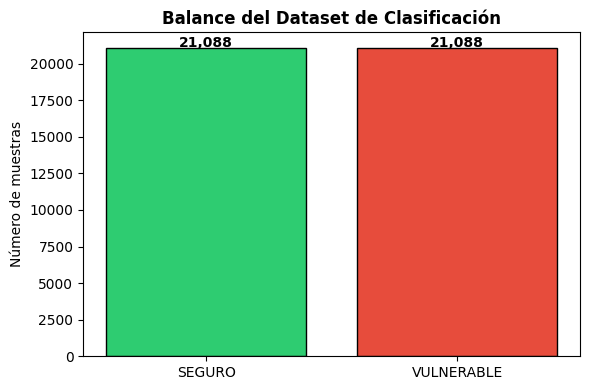

In [7]:
conteo = security_dataset['label'].value_counts()
labels_nombres = {0: 'SEGURO', 1: 'VULNERABLE'}

print('=== BALANCE DEL DATASET FINAL ===')
for lbl, cnt in conteo.items():
    pct = cnt / len(security_dataset) * 100
    print(f'  {labels_nombres[lbl]:12s}: {cnt:,} ({pct:.2f}%)')

ratio = conteo.max() / conteo.min()
print(f'\n  Ratio desbalance : {ratio:.3f}:1')
print(f'  Estado           : {"✓ BALANCEADO" if ratio < 1.5 else "⚠ DESBALANCEADO"}')

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
colores = ['#2ecc71', '#e74c3c']
ax.bar([labels_nombres[k] for k in conteo.index], conteo.values, color=colores, edgecolor='black')
ax.set_title('Balance del Dataset de Clasificación', fontweight='bold')
ax.set_ylabel('Número de muestras')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Análisis de longitud de código por clase

=== LONGITUD DE CÓDIGO POR CLASE ===
              count   mean    std   min    25%    50%    75%     max
SEGURO      21088.0  813.1  231.9  21.0  660.0  829.0  953.0  1666.0
VULNERABLE  21088.0  688.2  198.7  22.0  527.0  714.0  840.0  1517.0


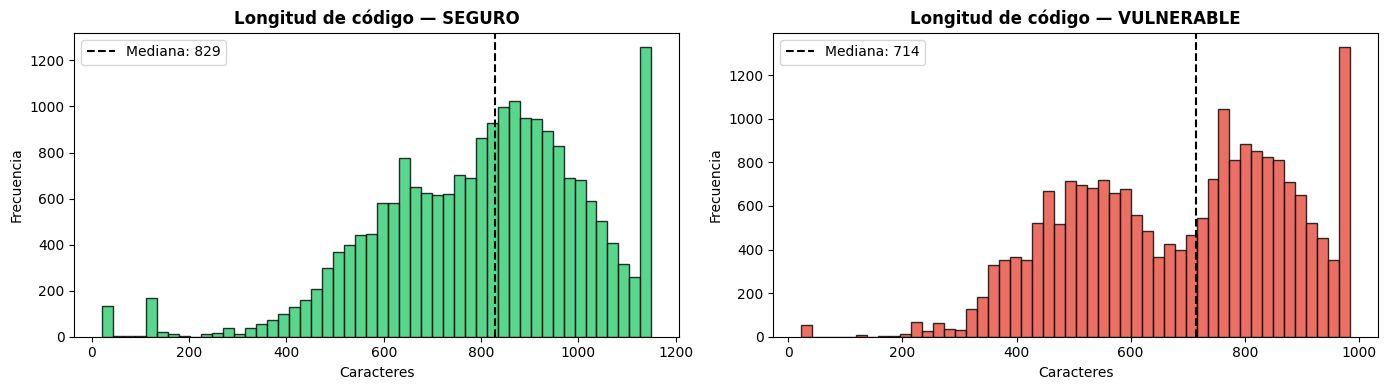

In [8]:
security_dataset['longitud'] = security_dataset['code'].str.len()

print('=== LONGITUD DE CÓDIGO POR CLASE ===')
stats = security_dataset.groupby('label')['longitud'].describe()
stats.index = [labels_nombres[i] for i in stats.index]
print(stats.round(1))

# Histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (lbl, nombre, color) in zip(axes, [(0,'SEGURO','#2ecc71'),(1,'VULNERABLE','#e74c3c')]):
    data = security_dataset[security_dataset['label']==lbl]['longitud']
    ax.hist(data.clip(upper=data.quantile(0.95)), bins=50, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'Longitud de código — {nombre}', fontweight='bold')
    ax.set_xlabel('Caracteres')
    ax.set_ylabel('Frecuencia')
    ax.axvline(data.median(), color='black', linestyle='--', label=f'Mediana: {data.median():.0f}')
    ax.legend()
plt.tight_layout()
plt.show()

security_dataset.drop(columns=['longitud'], inplace=True)

## 7. Distribución por tipo de vulnerabilidad en las muestras VULNERABLE

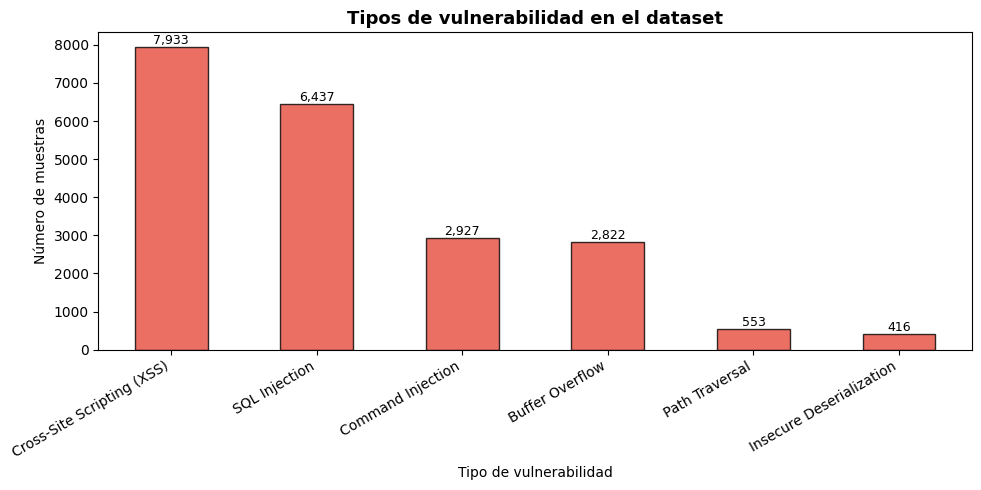


Distribución:
  Cross-Site Scripting (XSS)         : 7,933 (37.6%)
  SQL Injection                      : 6,437 (30.5%)
  Command Injection                  : 2,927 (13.9%)
  Buffer Overflow                    : 2,822 (13.4%)
  Path Traversal                     : 553 (2.6%)
  Insecure Deserialization           : 416 (2.0%)


In [9]:
# Recuperar tipo de vulnerabilidad para las muestras vulnerables
df_tipo = df.reset_index(drop=True)
tipos = df_tipo['vulnerability_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
tipos.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_title('Tipos de vulnerabilidad en el dataset', fontweight='bold', fontsize=13)
ax.set_ylabel('Número de muestras')
ax.set_xlabel('Tipo de vulnerabilidad')
plt.xticks(rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('\nDistribución:')
for tipo, cnt in tipos.items():
    pct = cnt / tipos.sum() * 100
    print(f'  {tipo:<35}: {cnt:,} ({pct:.1f}%)')

## 8. Guardar dataset final

In [10]:
security_dataset.to_csv(OUT_PATH, index=False)

print(f'✓ Dataset guardado en: {OUT_PATH}')
print(f'  Filas  : {len(security_dataset):,}')
print(f'  SEGURO    (0): {(security_dataset["label"]==0).sum():,}')
print(f'  VULNERABLE(1): {(security_dataset["label"]==1).sum():,}')

✓ Dataset guardado en: ..\data\processed\security_dataset.csv
  Filas  : 42,176
  SEGURO    (0): 21,088
  VULNERABLE(1): 21,088


## Resumen

| Paso | Acción | Resultado |
|------|--------|-----------|
| Carga | `vulnerability_fix_dataset.csv` | 35,000 registros |
| Deduplicación | `drop_duplicates()` | −2,517 |
| Filtro texto | Eliminar `fixed_code` explicativo | −11,395 |
| Etiquetado | `vulnerable_code→1`, `fixed_code→0` | ×2 muestras |
| Shuffle | `random_state=42` | — |
| **Dataset final** | `security_dataset.csv` | **~42,176 filas, 50/50** |